# Hodge split of cycle modes

This notebook shows how `hodge_decompose_modes` splits stored
eigenvector columns into combinatorial gradient, curl, and
harmonic blocks on an oriented 6-cycle. Reach for it when a
mode shape is already stored and the question is whether that
column is a potential-driven 1-cochain, a face-free
circulation, or a constant 0-cochain. When $N=E$, pass
`degree` explicitly: inference prefers $k=0$.

**Honesty.** This is a combinatorial Hodge split
(`hodge_decompose_modes`), not physical circulation, not
`koopman="hodge"`, and not TopologicX / sheaf parity. Face curl is
not shipped ($k\in\{0,1\}$). This notebook does **not** download
METR-LA.


## Setup

Package version, oriented-cycle helpers, and the relative L2
mass $\|\mathrm{part}\|_2/\|\mathrm{mode}\|_2$ (not a squared
energy share).


In [1]:
from __future__ import annotations

import os
import warnings

warnings.filterwarnings("ignore", message="IProgress not found")

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch

import koopman_graph
from koopman_graph.analysis import HodgeModeComponents, hodge_decompose_modes
from koopman_graph.observables import boundary_incidence_b1
from koopman_graph.spectrum_types import KoopmanSpectrum, compute_spectrum

CYCLE_N = 6
ATOL = 1e-6

print("koopman_graph", koopman_graph.__version__)


def cycle_edge_index(num_nodes: int) -> torch.Tensor:
    tails = torch.arange(num_nodes, dtype=torch.long)
    heads = torch.roll(tails, -1)
    return torch.stack((tails, heads), dim=0)


def spectrum_from_columns(columns: torch.Tensor) -> KoopmanSpectrum:
    modes = columns.to(dtype=torch.complex128)
    n_modes = int(modes.shape[1])
    eigenvalues = torch.ones(n_modes, dtype=torch.complex128)
    return KoopmanSpectrum(
        eigenvalues=eigenvalues,
        eigenvectors=modes,
        magnitudes=eigenvalues.abs(),
        growth_rates=torch.zeros(n_modes, dtype=torch.float64),
        frequencies=torch.zeros(n_modes, dtype=torch.float64),
        time_step=1.0,
    )


def relative_l2_mass(part: torch.Tensor, mode: torch.Tensor) -> float:
    """||part||_2 / ||mode||_2; not a squared energy fraction."""
    return float(
        torch.linalg.vector_norm(part).item()
        / torch.linalg.vector_norm(mode).item()
    )


koopman_graph 0.15.0


## Motivation and background

Stored Koopman columns are just vectors. The naive check is
to form $\ker L_k$ by hand and test membership. That is
enough on a 6-cycle if the only question is yes or no. It
does not report how much of the column sits in each Hodge
block, and it does not resolve $0$-cochains from
$1$-cochains when both have length $N=E$.

Lim (2020) splits a cochain into gradient, curl, and
harmonic parts (Lim, *SIAM Review*, 2020;
[doi:10.1137/18M1223101](https://doi.org/10.1137/18M1223101)).
On a consistently oriented cycle the circulation spans
$\ker L_1=\ker B_1$, with $L_1=B_1^{\top}B_1$ when faces
are absent. Constants span $\ker L_0=\ker B_1^{\top}$,
with $L_0=B_1 B_1^{\top}$. That algebraic kernel is not a
validated current.

`hodge_decompose_modes` projects stored columns onto those
blocks. Face-based $k=1$ curl ($\operatorname{im} B_2$) is
not shipped. When $N=E$ and `degree` is omitted, inference
returns $k=0$.


## Minimal example

All-ones edge weights on the cycle, passed as a $1$-cochain
with `degree=1`. Look for harmonic relative $L^2$ mass $1$
and a curl block that is exactly zero (structural, not a
$10^{-16}$ residual).


In [2]:
edge_index = cycle_edge_index(CYCLE_N)
circulation = torch.ones(CYCLE_N, dtype=torch.float64)
spectrum = spectrum_from_columns(circulation.unsqueeze(1))
parts = hodge_decompose_modes(
    spectrum, edge_index, num_nodes=CYCLE_N, degree=1
)
assert isinstance(parts, HodgeModeComponents)
mode = spectrum.eigenvectors[:, 0]
print("relative L2 mass harmonic", relative_l2_mass(parts.harmonic[:, 0], mode))
print("relative L2 mass gradient", relative_l2_mass(parts.gradient[:, 0], mode))
print("relative L2 mass curl", relative_l2_mass(parts.curl[:, 0], mode))
print("curl exactly zero", bool(torch.equal(parts.curl, torch.zeros_like(parts.curl))))
assert abs(relative_l2_mass(parts.harmonic[:, 0], mode) - 1.0) < ATOL
assert relative_l2_mass(parts.gradient[:, 0], mode) < ATOL
assert relative_l2_mass(parts.curl[:, 0], mode) < ATOL
assert torch.equal(parts.curl, torch.zeros_like(parts.curl))


relative L2 mass harmonic 1.0000000000000002
relative L2 mass gradient 3.4450388676262767e-16
relative L2 mass curl 0.0
curl exactly zero True


## Progressive deep dive

A gradient flow $B_1^{\top}\varphi$ is **not** harmonic.
Reconstruct the stored column as gradient + curl + harmonic.


In [3]:
incidence = boundary_incidence_b1(edge_index, num_nodes=CYCLE_N).to(
    dtype=torch.float64
)
potential = torch.tensor(
    [1.0, -0.5, 0.25, 0.0, -0.75, 1.0], dtype=torch.float64
)
flow = incidence.T @ potential
grad_spectrum = spectrum_from_columns(flow.unsqueeze(1))
grad_parts = hodge_decompose_modes(
    grad_spectrum, edge_index, num_nodes=CYCLE_N, degree=1
)
gmode = grad_spectrum.eigenvectors[:, 0]
print(
    "gradient flow relative L2 mass harmonic",
    relative_l2_mass(grad_parts.harmonic[:, 0], gmode),
)
print(
    "gradient flow relative L2 mass gradient",
    relative_l2_mass(grad_parts.gradient[:, 0], gmode),
)
assert relative_l2_mass(grad_parts.gradient[:, 0], gmode) > 1.0 - ATOL
assert relative_l2_mass(grad_parts.harmonic[:, 0], gmode) < ATOL
reconstructed = grad_parts.gradient + grad_parts.curl + grad_parts.harmonic
assert torch.allclose(
    reconstructed, grad_spectrum.eigenvectors, atol=ATOL, rtol=0.0
)
print("reconstruction matches stored columns")


gradient flow relative L2 mass harmonic 3.117457104162384e-16
gradient flow relative L2 mass gradient 1.0
reconstruction matches stored columns


Omit `degree` on the same all-ones column. Because $N=E=6$,
inference returns $k=0$: curl is a residual near $10^{-16}$,
not a structural zero.

In [4]:
inferred = hodge_decompose_modes(
    spectrum, edge_index, num_nodes=CYCLE_N
)
print("N", CYCLE_N, "E", int(edge_index.shape[1]))
print(
    "inferred curl exactly zero",
    bool(torch.equal(inferred.curl, torch.zeros_like(inferred.curl))),
)
print(
    "inferred gradient exactly zero",
    bool(torch.equal(inferred.gradient, torch.zeros_like(inferred.gradient))),
)
print(
    "inferred relative L2 mass curl",
    relative_l2_mass(inferred.curl[:, 0], mode),
)
assert torch.equal(
    inferred.gradient, torch.zeros_like(inferred.gradient)
)
assert not torch.equal(inferred.curl, torch.zeros_like(inferred.curl))
assert relative_l2_mass(inferred.curl[:, 0], mode) < ATOL


N 6 E 6
inferred curl exactly zero False
inferred gradient exactly zero True
inferred relative L2 mass curl 2.841075513518106e-16


## Results

This cell rebuilds the cycle so it does not depend on the
minimal-example or deep-dive names. $L_1=B_1^{\top}B_1$
annihilates the `degree=1` circulation. $L_0=B_1 B_1^{\top}$
annihilates the `degree=0` constant. On this cycle the same
all-ones vector is both $1_E$ and $1_N$, so both Laplacians
annihilate it; the structural zero (curl at $k=1$, gradient
at $k=0$) is what identifies the split, not the residual
alone. Stacked columns come first; a `compute_spectrum`
leading mode of a constructed cycle map follows Figure 1.


In [5]:
edge_index = cycle_edge_index(CYCLE_N)
incidence = boundary_incidence_b1(edge_index, num_nodes=CYCLE_N).to(
    dtype=torch.float64
)
ones = torch.ones(CYCLE_N, dtype=torch.float64)
potential = torch.tensor(
    [1.0, -0.5, 0.25, 0.0, -0.75, 1.0], dtype=torch.float64
)
flow = incidence.T @ potential

circ_spectrum = spectrum_from_columns(ones.unsqueeze(1))
circ_parts = hodge_decompose_modes(
    circ_spectrum, edge_index, num_nodes=CYCLE_N, degree=1
)
const_spectrum = spectrum_from_columns(ones.unsqueeze(1))
const_parts = hodge_decompose_modes(
    const_spectrum, edge_index, num_nodes=CYCLE_N, degree=0
)
grad_spectrum = spectrum_from_columns(flow.unsqueeze(1))
grad_parts = hodge_decompose_modes(
    grad_spectrum, edge_index, num_nodes=CYCLE_N, degree=1
)

laplacian_1 = incidence.T @ incidence
laplacian_0 = incidence @ incidence.T
circ_leftover = laplacian_1 @ circ_parts.harmonic[:, 0].real
const_leftover = laplacian_0 @ const_parts.harmonic[:, 0].real
print("||L_1 circulation harmonic||", float(torch.linalg.vector_norm(circ_leftover)))
print("||L_0 constant harmonic||", float(torch.linalg.vector_norm(const_leftover)))
print("||L_1 1||", float(torch.linalg.vector_norm(laplacian_1 @ ones)))
print("||L_0 1||", float(torch.linalg.vector_norm(laplacian_0 @ ones)))
print(
    "circulation curl exactly zero",
    bool(torch.equal(circ_parts.curl, torch.zeros_like(circ_parts.curl))),
)
print(
    "constant gradient exactly zero",
    bool(torch.equal(const_parts.gradient, torch.zeros_like(const_parts.gradient))),
)
assert float(torch.linalg.vector_norm(circ_leftover)) < ATOL
assert float(torch.linalg.vector_norm(const_leftover)) < ATOL
assert torch.equal(circ_parts.curl, torch.zeros_like(circ_parts.curl))
assert torch.equal(
    const_parts.gradient, torch.zeros_like(const_parts.gradient)
)


||L_1 circulation harmonic|| 1.1957467920563633e-15
||L_0 constant harmonic|| 1.961044852356119e-15
||L_1 1|| 0.0
||L_0 1|| 0.0
circulation curl exactly zero True
constant gradient exactly zero True


Figure 1 reports relative $L^2$ mass
$\|\mathrm{part}\|_2/\|\mathrm{mode}\|_2$ for three stacked
columns. Look for a circulation harmonic bar of $1$ with an
exactly zero curl bar, a gradient-flow gradient bar of $1$,
and a constant-$0$-cochain harmonic bar of $1$ with an
exactly zero gradient bar.

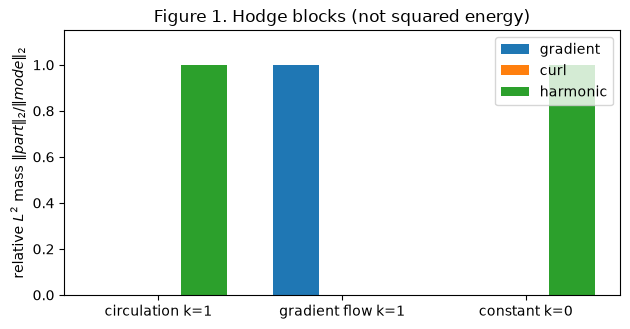

In [6]:
columns = [
    ("circulation k=1", circ_parts, circ_spectrum.eigenvectors[:, 0]),
    ("gradient flow k=1", grad_parts, grad_spectrum.eigenvectors[:, 0]),
    ("constant k=0", const_parts, const_spectrum.eigenvectors[:, 0]),
]
grads = [relative_l2_mass(parts.gradient[:, 0], mode) for _, parts, mode in columns]
curls = [relative_l2_mass(parts.curl[:, 0], mode) for _, parts, mode in columns]
harms = [relative_l2_mass(parts.harmonic[:, 0], mode) for _, parts, mode in columns]
labels = [name for name, _, _ in columns]
x = list(range(len(labels)))
width = 0.25

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.bar([i - width for i in x], grads, width, label="gradient")
ax.bar(x, curls, width, label="curl")
ax.bar([i + width for i in x], harms, width, label="harmonic")
ax.set_xticks(x, labels)
ax.set_ylabel(r"relative $L^2$ mass $\|part\|_2/\|mode\|_2$")
ax.set_title("Figure 1. Hodge blocks (not squared energy)")
ax.set_ylim(0.0, 1.15)
ax.legend()
fig.tight_layout()
plt.show()


The next cell is a `compute_spectrum` leading mode, not a
hand-stacked column. A seeded linear map is built so that
its largest-magnitude eigenvector is the cycle circulation
(QR with first column all-ones). This is an
eigendecomposition of a constructed operator, not a trained
`GraphKoopman` fit and not METR-LA. Pass `degree=1`. Look
for harmonic relative $L^2$ mass $1$ and a structural zero
curl.

In [7]:
torch.manual_seed(0)
edge_index = cycle_edge_index(CYCLE_N)
raw = torch.randn(CYCLE_N, CYCLE_N, dtype=torch.float64)
raw[:, 0] = 1.0
basis, _ = torch.linalg.qr(raw)
eigenvalues = torch.tensor(
    [0.9, 0.5, 0.3, 0.2, 0.1, 0.05], dtype=torch.float64
)
operator = basis @ torch.diag(eigenvalues) @ basis.T
fitted = compute_spectrum(operator, time_step=1.0)
fitted_parts = hodge_decompose_modes(
    fitted, edge_index, num_nodes=CYCLE_N, degree=1
)
leading = fitted.eigenvectors[:, 0]
print("|lambda_0|", float(fitted.magnitudes[0].real))
print(
    "leading relative L2 mass harmonic",
    relative_l2_mass(fitted_parts.harmonic[:, 0], leading),
)
print(
    "leading relative L2 mass gradient",
    relative_l2_mass(fitted_parts.gradient[:, 0], leading),
)
print(
    "leading curl exactly zero",
    bool(torch.equal(fitted_parts.curl, torch.zeros_like(fitted_parts.curl))),
)
assert abs(float(fitted.magnitudes[0].real) - 0.9) < ATOL
assert relative_l2_mass(fitted_parts.harmonic[:, 0], leading) > 1.0 - ATOL
assert relative_l2_mass(fitted_parts.gradient[:, 0], leading) < ATOL
assert torch.equal(
    fitted_parts.curl, torch.zeros_like(fitted_parts.curl)
)

|lambda_0| 0.899999999999999
leading relative L2 mass harmonic 1.0
leading relative L2 mass gradient 6.079983772422532e-16
leading curl exactly zero True


## Interpretation / discussion

The helper replaces a hand $\ker L_k$ membership test with
a three-block split of a stored column. On this cycle a
`degree=1` circulation is harmonic and a potential-driven
flow is gradient. A `degree=0` constant is the $0$-cochain
analogue. The leading `compute_spectrum` mode of the
constructed cycle map is the same harmonic 1-cochain. That
is analysis of stored mode shapes. It does not change the
factory default, is not a trained `GraphKoopman` fit, and
is not `koopman="hodge"`.

The method breaks down when $N=E$ and `degree` is omitted:
inference returns $k=0$, and a Laplacian residual on the
all-ones vector cannot tell $L_0$ from $L_1$. Face-based
$k=1$ curl is unshipped, so the curl block at $k=1$ is
identically zero. Forming $\ker L_k$ remains cheaper if
the only question is membership.


## Takeaways

- Use `hodge_decompose_modes` on stored mode shapes,
  including `compute_spectrum` columns, when the question
  is which combinatorial Hodge block holds the column
  ($k\in\{0,1\}$ on a static signed $B_1$).
- When $N=E$, pass `degree=1` for a 1-cochain. Inference
  prefers $k=0`.
- Relative $L^2$ mass is $\|\mathrm{part}\|_2/\|\mathrm{mode}\|_2$,
  not a squared energy share. $L_0=B_1 B_1^{\top}$ and
  $L_1=B_1^{\top}B_1$ are different operators.
- $k\in\{0,1\}$; face curl is not shipped.
- Not physical circulation, not TopologicX, not a factory
  kind, and not a trained `GraphKoopman` fit.


## Further reading

- Sphinx: [api](../docs/source/api.rst)
  (`hodge_decompose_modes`),
  [faq](../docs/source/faq.rst)
  (Hodge mode components),
  [limitations](../docs/source/limitations.rst)
  (node vs cochain)
- Lim (2020), *SIAM Review*
  ([doi:10.1137/18M1223101](https://doi.org/10.1137/18M1223101);
  `Lim2020Hodge`)
- Example [07_koopman_spectrum.ipynb](07_koopman_spectrum.ipynb)
  (`compute_spectrum`)
- Example [43_tdl_sheaf_cell_ablation.ipynb](43_tdl_sheaf_cell_ablation.ipynb)
